# Hyperbolic K-Means Clustering on the Poincaré Disk

This notebook demonstrates clustering in **hyperbolic space** using the Poincaré disk model.

## Why Hyperbolic Space?

Imagine a tree — a root node branches into children, each of which branches further. The number of nodes grows *exponentially* with depth. Euclidean space can't embed such structures without heavy distortion, because flat space only grows *polynomially* in volume with radius.

**Hyperbolic space** is the opposite of a sphere:
- A sphere has *positive* curvature (like the outside of a ball) — parallel lines converge
- Flat space has *zero* curvature — parallel lines stay parallel
- Hyperbolic space has *negative* curvature (like a saddle or Pringle chip) — parallel lines diverge

This means hyperbolic space has room to "spread out" exponentially, making it a natural home for **hierarchical and tree-like data** (taxonomies, org charts, social networks, phylogenetic trees).

## The Poincaré Disk Model

The Poincaré disk maps the *entire* infinite hyperbolic plane into the interior of a unit circle ($\|x\| < 1$). Key properties:
- The **center** of the disk represents "normal" space — distances work roughly like Euclidean
- Near the **boundary**, space is "compressed" — points that look close in the disk are actually very far apart in hyperbolic distance
- **Geodesics** (shortest paths) are arcs of circles that intersect the boundary at right angles

## 1. Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
import matplotlib.colors as mcolors

np.random.seed(42)

print("Setup complete!")

Setup complete!


## 2. Generate Pre-Clustered Points in the Poincaré Disk

We place seed centers at various "depths" inside the disk — some near the center (shallow in the hierarchy) and some near the boundary (deep). Points are scattered around each center using **Möbius translations**, which are the natural way to "move" in hyperbolic space.

In [2]:
def mobius_addition(a, b):
    """
    Möbius addition: a ⊕ b in the Poincaré disk.
    This is the hyperbolic equivalent of vector addition.
    
    For 2D points a = (a1, a2) and b = (b1, b2):
    a ⊕ b = ((1 + 2<a,b> + |b|²)a + (1 - |a|²)b) / (1 + 2<a,b> + |a|²|b|²)
    """
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    
    a_dot_b = np.sum(a * b, axis=-1, keepdims=True)
    a_sq = np.sum(a**2, axis=-1, keepdims=True)
    b_sq = np.sum(b**2, axis=-1, keepdims=True)
    
    numerator = (1 + 2 * a_dot_b + b_sq) * a + (1 - a_sq) * b
    denominator = 1 + 2 * a_dot_b + a_sq * b_sq
    
    result = numerator / denominator
    
    # Ensure result stays inside the disk (numerical safety)
    norm = np.sqrt(np.sum(result**2, axis=-1, keepdims=True))
    max_norm = 0.999
    result = np.where(norm > max_norm, result * max_norm / norm, result)
    
    return result


def generate_hyperbolic_clusters(n_points=300, n_clusters=5, spread=0.08, seed=42):
    """
    Generate pre-clustered points in the Poincaré disk.
    
    Centers are placed at varying radii to show the effect of
    hyperbolic geometry — near-boundary clusters look tiny in
    Euclidean terms but are just as "spread out" hyperbolically.
    """
    rng = np.random.default_rng(seed)
    
    # Seed centers: (radius, angle) — mix of shallow and deep positions
    center_configs = [
        (0.15, 0.0),       # near center (shallow)
        (0.50, 2.0),       # mid-depth
        (0.75, 4.2),       # deeper
        (0.88, 1.2),       # near boundary (deep)
        (0.60, 5.0),       # mid-depth
    ]
    
    centers = []
    for r, theta in center_configs[:n_clusters]:
        centers.append(np.array([r * np.cos(theta), r * np.sin(theta)]))
    centers = np.array(centers)
    
    points_per_cluster = n_points // n_clusters
    all_points = []
    all_labels = []
    
    for i in range(n_clusters):
        n = points_per_cluster if i < n_clusters - 1 else n_points - points_per_cluster * (n_clusters - 1)
        
        # Generate small perturbations near the origin
        perturbations = rng.normal(0, spread, size=(n, 2))
        # Clip to stay well inside the disk
        pert_norms = np.sqrt(np.sum(perturbations**2, axis=1, keepdims=True))
        perturbations = np.where(pert_norms > 0.4, perturbations * 0.4 / pert_norms, perturbations)
        
        # Translate perturbations to the cluster center via Möbius addition
        cluster_points = mobius_addition(centers[i], perturbations)
        
        all_points.append(cluster_points)
        all_labels.append(np.full(n, i))
    
    return np.vstack(all_points), np.concatenate(all_labels), centers


# Generate the dataset
points, true_labels, seed_centers = generate_hyperbolic_clusters(
    n_points=300, n_clusters=5, spread=0.08
)

print(f"Generated {len(points)} points in {len(np.unique(true_labels))} clusters")
print(f"Euclidean radii of seed centers: {[f'{np.linalg.norm(c):.2f}' for c in seed_centers]}")
print(f"All points inside unit disk: {np.all(np.linalg.norm(points, axis=1) < 1)}")

Generated 300 points in 5 clusters
Euclidean radii of seed centers: ['0.15', '0.50', '0.75', '0.88', '0.60']
All points inside unit disk: True


## 3. Poincaré Disk Distance

The hyperbolic distance between two points $u, v$ in the Poincaré disk is:

$$d(u, v) = \text{arcosh}\left(1 + \frac{2\|u - v\|^2}{(1 - \|u\|^2)(1 - \|v\|^2)}\right)$$

Notice how the denominator $(1 - \|u\|^2)(1 - \|v\|^2)$ **explodes** as points approach the boundary ($\|u\| \to 1$). A tiny Euclidean displacement near the boundary produces a **huge** hyperbolic distance.

In [3]:
def poincare_distance(u, v):
    """
    Hyperbolic distance in the Poincaré disk model.
    
    u, v: arrays of shape (..., 2)
    Returns: array of distances
    """
    u = np.asarray(u, dtype=np.float64)
    v = np.asarray(v, dtype=np.float64)
    
    diff_sq = np.sum((u - v)**2, axis=-1)
    u_sq = np.sum(u**2, axis=-1)
    v_sq = np.sum(v**2, axis=-1)
    
    # Clip for numerical safety near the boundary
    denom = np.clip((1 - u_sq) * (1 - v_sq), 1e-15, None)
    
    arg = 1 + 2 * diff_sq / denom
    arg = np.clip(arg, 1.0, None)  # arcosh domain: [1, inf)
    
    return np.arccosh(arg)


def poincare_distance_matrix(points, centers):
    """Distance matrix between all points and all centers. Shape: (n_points, n_centers)."""
    n_p = len(points)
    n_c = len(centers)
    dist_matrix = np.zeros((n_p, n_c))
    for j in range(n_c):
        dist_matrix[:, j] = poincare_distance(points, centers[j])
    return dist_matrix


# Sanity checks
origin = np.array([0.0, 0.0])

# Distance from origin to a point at Euclidean radius r is 2 * arctanh(r)
test_r = 0.5
test_point = np.array([test_r, 0.0])
d = poincare_distance(origin, test_point)
expected = 2 * np.arctanh(test_r)
print(f"Origin to (0.5, 0): d = {d:.4f}  expected = {expected:.4f}")

# Near the boundary: distance grows dramatically
for r in [0.1, 0.5, 0.9, 0.95, 0.99]:
    p = np.array([r, 0.0])
    d = poincare_distance(origin, p)
    print(f"  Euclidean radius {r:.2f}  →  Hyperbolic distance from origin: {d:.3f}")

Origin to (0.5, 0): d = 1.0986  expected = 1.0986
  Euclidean radius 0.10  →  Hyperbolic distance from origin: 0.201
  Euclidean radius 0.50  →  Hyperbolic distance from origin: 1.099
  Euclidean radius 0.90  →  Hyperbolic distance from origin: 2.944
  Euclidean radius 0.95  →  Hyperbolic distance from origin: 3.664
  Euclidean radius 0.99  →  Hyperbolic distance from origin: 5.293


## 4. Hyperbolic K-Means

Two key differences from Euclidean K-means:
1. **Distance:** Poincaré distance instead of Euclidean
2. **Centroid update:** We use the **Einstein midpoint** — the hyperbolic equivalent of averaging. It computes a weighted mean in the Klein model (where the formula is simpler) and maps back to Poincaré.

In [4]:
def poincare_to_klein(p):
    """Map from Poincaré disk to Klein disk model."""
    p = np.asarray(p, dtype=np.float64)
    p_sq = np.sum(p**2, axis=-1, keepdims=True)
    return 2 * p / (1 + p_sq)


def klein_to_poincare(k):
    """Map from Klein disk to Poincaré disk model."""
    k = np.asarray(k, dtype=np.float64)
    k_sq = np.sum(k**2, axis=-1, keepdims=True)
    denom = 1 + np.sqrt(np.clip(1 - k_sq, 1e-15, None))
    return k / denom


def einstein_midpoint(points):
    """
    Compute the Einstein midpoint (hyperbolic centroid) of a set of points.
    
    Algorithm:
    1. Map points from Poincaré to Klein model
    2. Compute Lorentz-factor-weighted average in Klein model
    3. Map result back to Poincaré model
    """
    points = np.asarray(points, dtype=np.float64)
    
    # Lorentz factors (gamma) for each point
    p_sq = np.sum(points**2, axis=-1)  # ||p||^2 in Poincaré
    gamma = 1.0 / np.sqrt(np.clip(1 - p_sq, 1e-15, None))  # Lorentz factor
    
    # Map to Klein
    klein_points = poincare_to_klein(points)
    
    # Weighted average in Klein model
    weights = gamma  # shape: (n_points,)
    weighted_sum = np.sum(weights[:, np.newaxis] * klein_points, axis=0)
    klein_mean = weighted_sum / np.sum(weights)
    
    # Ensure it stays inside the disk
    km_norm = np.linalg.norm(klein_mean)
    if km_norm >= 1.0:
        klein_mean = klein_mean * 0.999 / km_norm
    
    # Map back to Poincaré
    return klein_to_poincare(klein_mean)


def hyperbolic_kmeans(points, k=5, max_iter=100, tol=1e-6, seed=123):
    """
    K-means in the Poincaré disk using hyperbolic distance
    and Einstein midpoint centroids.
    """
    rng = np.random.default_rng(seed)
    n = len(points)
    
    # Initialize centroids as random data points
    init_idx = rng.choice(n, size=k, replace=False)
    centroids = points[init_idx].copy()
    
    history = []
    labels = np.zeros(n, dtype=int)
    
    for iteration in range(max_iter):
        # Assignment step
        dist_matrix = poincare_distance_matrix(points, centroids)
        labels = np.argmin(dist_matrix, axis=1)
        
        total_dist = np.sum(dist_matrix[np.arange(n), labels])
        history.append(total_dist)
        
        # Update step: Einstein midpoint per cluster
        new_centroids = np.zeros_like(centroids)
        for j in range(k):
            members = points[labels == j]
            if len(members) == 0:
                new_centroids[j] = points[rng.choice(n)]
            else:
                new_centroids[j] = einstein_midpoint(members)
        
        # Check convergence
        shift = poincare_distance(centroids, new_centroids)
        centroids = new_centroids
        
        if np.max(shift) < tol:
            print(f"Converged at iteration {iteration + 1}")
            break
    else:
        print(f"Reached max iterations ({max_iter})")
    
    return labels, centroids, history


# Run hyperbolic K-means
K = 5
hyp_labels, hyp_centroids, hyp_history = hyperbolic_kmeans(
    points, k=K, max_iter=100
)

print(f"\nCluster sizes: {[np.sum(hyp_labels == i) for i in range(K)]}")
print(f"Final total hyperbolic distance: {hyp_history[-1]:.4f}")

Converged at iteration 3

Cluster sizes: [np.int64(60), np.int64(60), np.int64(60), np.int64(60), np.int64(60)]
Final total hyperbolic distance: 58.7841


## 5. Visualizations

### 5a. Poincaré Disk — Clustered Points with Geodesics

Geodesics in the Poincaré disk are arcs of circles perpendicular to the boundary. We draw them from each point to its centroid to visualize cluster membership.

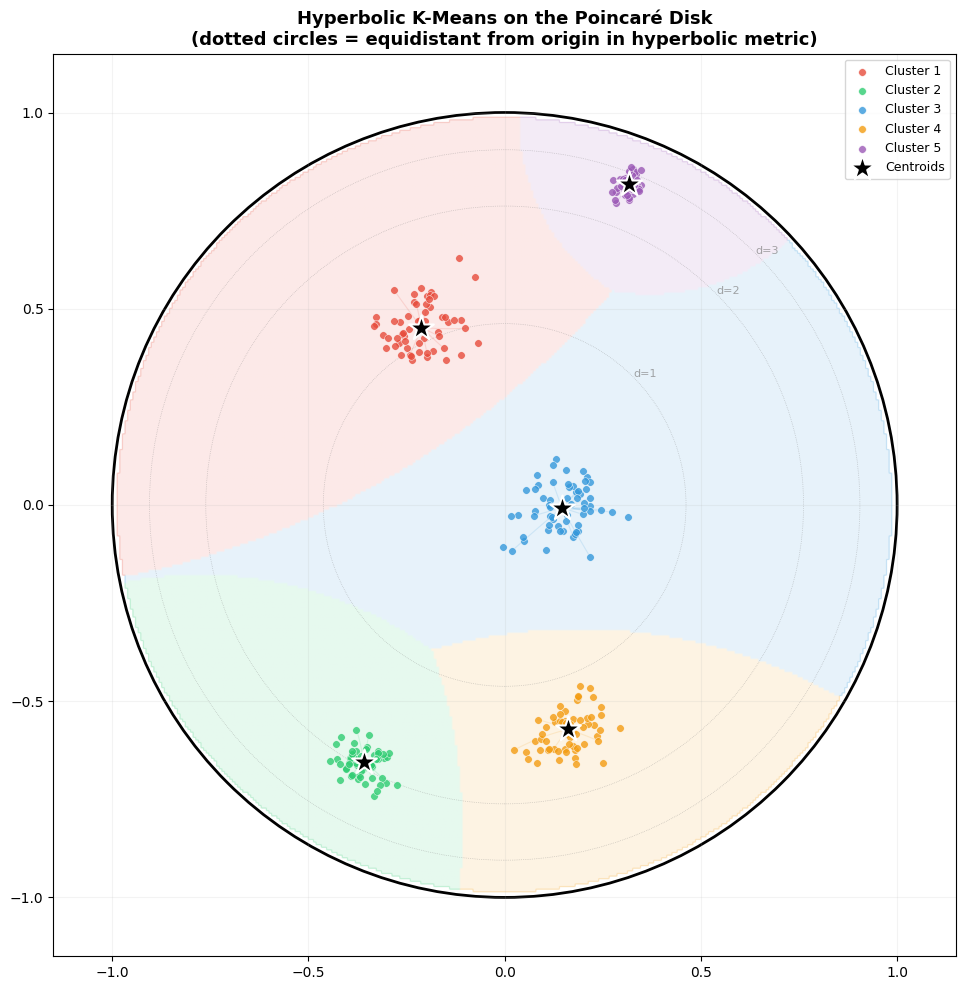

In [5]:
def geodesic_arc(p1, p2, n_segments=50):
    """
    Approximate a geodesic arc in the Poincaré disk between p1 and p2
    by interpolating along the Möbius gyration.
    
    Uses the formula: gamma(t) = p1 ⊕ (t * (-p1 ⊕ p2))
    where ⊕ is Möbius addition.
    """
    p1 = np.asarray(p1, dtype=np.float64)
    p2 = np.asarray(p2, dtype=np.float64)
    
    # -p1 ⊕ p2 gives the "direction" from p1 to p2 in hyperbolic space
    neg_p1 = -p1
    direction = mobius_addition(neg_p1, p2)
    
    arc_points = []
    for t in np.linspace(0, 1, n_segments):
        # Scale direction by t
        d_norm = np.linalg.norm(direction)
        if d_norm < 1e-10:
            arc_points.append(p1)
            continue
        # t-scaled point in tangent space, mapped back
        t_dir = np.tanh(t * np.arctanh(d_norm)) * direction / d_norm
        point = mobius_addition(p1, t_dir)
        arc_points.append(point)
    
    return np.array(arc_points)


cluster_colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6']

fig, ax = plt.subplots(figsize=(10, 10))

# Draw the unit disk boundary
boundary = plt.Circle((0, 0), 1, fill=False, color='black', linewidth=2)
ax.add_patch(boundary)

# Background shading: assign each pixel to nearest centroid
grid_res = 300
gx = np.linspace(-1, 1, grid_res)
gy = np.linspace(-1, 1, grid_res)
gx_mesh, gy_mesh = np.meshgrid(gx, gy)
grid_pts = np.stack([gx_mesh.ravel(), gy_mesh.ravel()], axis=-1)

# Only points inside the disk
inside_mask = np.sum(grid_pts**2, axis=1) < 0.98  # slight margin
grid_labels_bg = np.full(len(grid_pts), -1)

if np.any(inside_mask):
    dists = poincare_distance_matrix(grid_pts[inside_mask], hyp_centroids)
    grid_labels_bg[inside_mask] = np.argmin(dists, axis=1)

grid_labels_img = grid_labels_bg.reshape(grid_res, grid_res)

# Create RGBA image for background
bg_rgba = np.ones((grid_res, grid_res, 4))  # white background
for i in range(K):
    mask_2d = grid_labels_img == i
    rgba = mcolors.to_rgba(cluster_colors[i], alpha=0.12)
    bg_rgba[mask_2d] = rgba

# Outside disk = white
outside_2d = grid_labels_img == -1
bg_rgba[outside_2d] = [1, 1, 1, 1]

ax.imshow(bg_rgba, extent=[-1, 1, -1, 1], origin='lower', aspect='equal')

# Draw geodesic arcs from a sample of points to their centroids
rng_vis = np.random.default_rng(77)
sample_idx = rng_vis.choice(len(points), size=60, replace=False)
for idx in sample_idx:
    p = points[idx]
    c = hyp_centroids[hyp_labels[idx]]
    arc = geodesic_arc(p, c, n_segments=30)
    ax.plot(arc[:, 0], arc[:, 1], color=cluster_colors[hyp_labels[idx]],
            alpha=0.15, linewidth=0.8)

# Plot points
for i in range(K):
    mask = hyp_labels == i
    ax.scatter(points[mask, 0], points[mask, 1],
               c=cluster_colors[i], s=30, alpha=0.8, edgecolors='white',
               linewidths=0.4, label=f'Cluster {i+1}', zorder=5)

# Plot centroids
ax.scatter(hyp_centroids[:, 0], hyp_centroids[:, 1],
           c='black', marker='*', s=350, edgecolors='white',
           linewidths=1.5, zorder=10, label='Centroids')

# Draw concentric hyperbolic distance circles from origin
for r_hyp in [1, 2, 3]:
    r_euc = np.tanh(r_hyp / 2)  # Euclidean radius corresponding to hyp distance from origin
    circle = plt.Circle((0, 0), r_euc, fill=False, color='gray',
                        linewidth=0.5, linestyle=':', alpha=0.5)
    ax.add_patch(circle)
    ax.annotate(f'd={r_hyp}', xy=(r_euc * 0.707, r_euc * 0.707),
                fontsize=8, color='gray', alpha=0.7)

ax.set_xlim(-1.15, 1.15)
ax.set_ylim(-1.15, 1.15)
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=9)
ax.set_title('Hyperbolic K-Means on the Poincaré Disk\n(dotted circles = equidistant from origin in hyperbolic metric)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.15)

plt.tight_layout()
plt.show()

### 5b. Convergence Plot

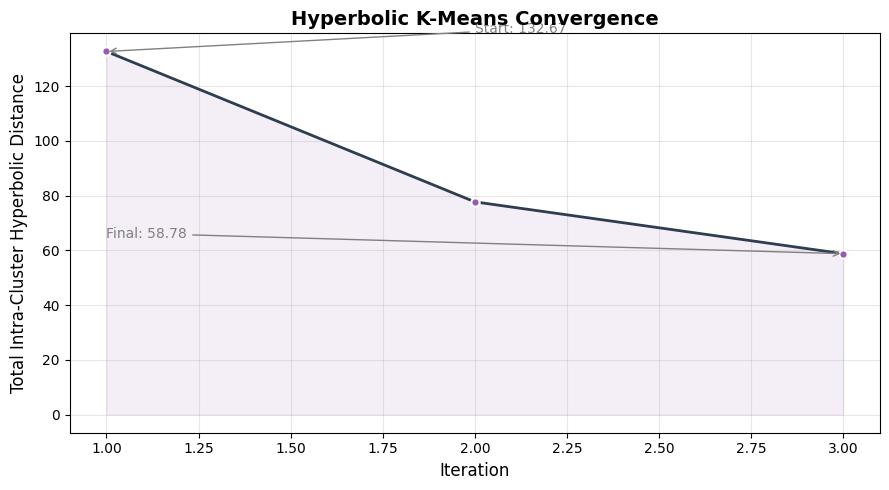

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

iterations = range(1, len(hyp_history) + 1)

ax.plot(iterations, hyp_history, 'o-', color='#2c3e50', markersize=6,
        linewidth=2, markerfacecolor='#9b59b6', markeredgecolor='white', markeredgewidth=1.5)

ax.fill_between(iterations, hyp_history, alpha=0.1, color='#9b59b6')

ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Total Intra-Cluster Hyperbolic Distance', fontsize=12)
ax.set_title('Hyperbolic K-Means Convergence', fontsize=14, fontweight='bold')

ax.annotate(f'Start: {hyp_history[0]:.2f}', xy=(1, hyp_history[0]),
            xytext=(2, hyp_history[0] * 1.05),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=10, color='gray')
ax.annotate(f'Final: {hyp_history[-1]:.2f}', xy=(len(hyp_history), hyp_history[-1]),
            xytext=(max(1, len(hyp_history) - 3), hyp_history[-1] * 1.1),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=10, color='gray')

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5c. Euclidean vs Hyperbolic Distance — The Key Insight

This visualization shows **why** you need hyperbolic distance for this kind of data. We run standard Euclidean K-means on the same points and compare.

In [7]:
def euclidean_kmeans(points, k=5, max_iter=100, tol=1e-6, seed=123):
    """Standard Euclidean K-means for comparison."""
    rng = np.random.default_rng(seed)
    n = len(points)
    
    init_idx = rng.choice(n, size=k, replace=False)
    centroids = points[init_idx].copy()
    
    history = []
    labels = np.zeros(n, dtype=int)
    
    for iteration in range(max_iter):
        # Euclidean distances
        dist_matrix = np.zeros((n, k))
        for j in range(k):
            dist_matrix[:, j] = np.linalg.norm(points - centroids[j], axis=1)
        labels = np.argmin(dist_matrix, axis=1)
        
        total_dist = np.sum(dist_matrix[np.arange(n), labels])
        history.append(total_dist)
        
        new_centroids = np.zeros_like(centroids)
        for j in range(k):
            members = points[labels == j]
            if len(members) == 0:
                new_centroids[j] = points[rng.choice(n)]
            else:
                new_centroids[j] = members.mean(axis=0)
        
        shift = np.max(np.linalg.norm(centroids - new_centroids, axis=1))
        centroids = new_centroids
        
        if shift < tol:
            break
    
    return labels, centroids, history


# Run Euclidean K-means on same data
euc_labels, euc_centroids, euc_history = euclidean_kmeans(points, k=K, max_iter=100)

print(f"Euclidean cluster sizes: {[np.sum(euc_labels == i) for i in range(K)]}")
print(f"Hyperbolic cluster sizes: {[np.sum(hyp_labels == i) for i in range(K)]}")

Euclidean cluster sizes: [np.int64(60), np.int64(60), np.int64(60), np.int64(60), np.int64(60)]
Hyperbolic cluster sizes: [np.int64(60), np.int64(60), np.int64(60), np.int64(60), np.int64(60)]


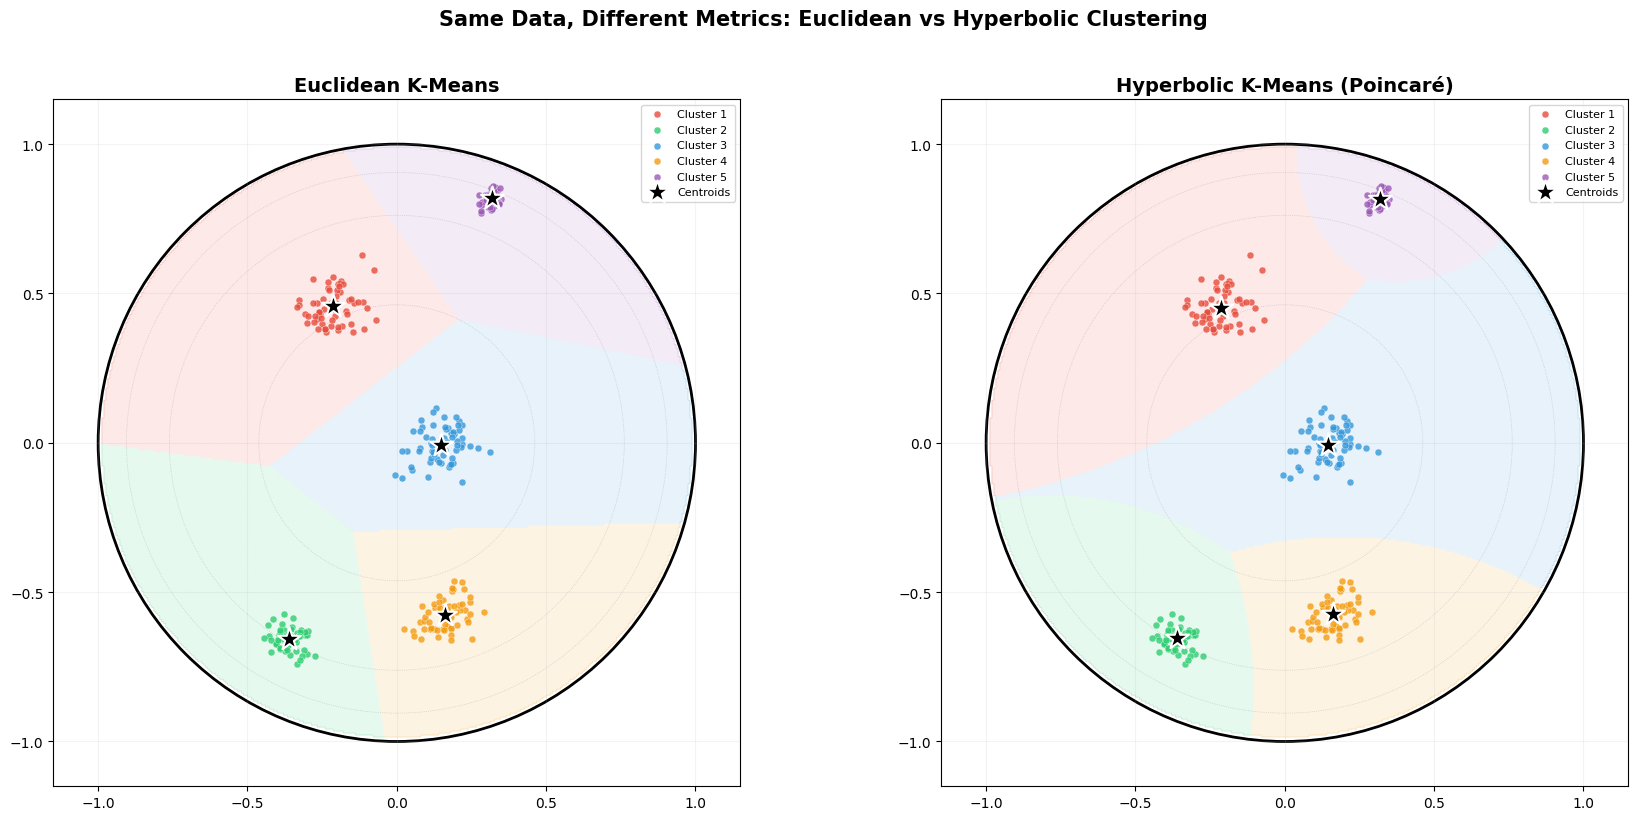

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

titles = ['Euclidean K-Means', 'Hyperbolic K-Means (Poincaré)']
all_labels_list = [euc_labels, hyp_labels]
all_centroids_list = [euc_centroids, hyp_centroids]

for idx, (ax, title, lbls, cents) in enumerate(
    zip(axes, titles, all_labels_list, all_centroids_list)
):
    # Disk boundary
    boundary = plt.Circle((0, 0), 1, fill=False, color='black', linewidth=2)
    ax.add_patch(boundary)
    
    # Background Voronoi shading
    grid_labels_local = np.full(len(grid_pts), -1)
    if idx == 0:  # Euclidean
        for j in range(K):
            dists_j = np.linalg.norm(grid_pts[inside_mask] - cents[j], axis=1)
            if j == 0:
                min_dists = dists_j.copy()
                grid_labels_local[inside_mask] = 0
            else:
                closer = dists_j < min_dists
                min_dists[closer] = dists_j[closer]
                temp = grid_labels_local[inside_mask].copy()
                temp[closer] = j
                grid_labels_local[inside_mask] = temp
    else:  # Hyperbolic
        dists_h = poincare_distance_matrix(grid_pts[inside_mask], cents)
        grid_labels_local[inside_mask] = np.argmin(dists_h, axis=1)
    
    grid_img = grid_labels_local.reshape(grid_res, grid_res)
    bg = np.ones((grid_res, grid_res, 4))
    for i in range(K):
        mask_2d = grid_img == i
        bg[mask_2d] = mcolors.to_rgba(cluster_colors[i], alpha=0.12)
    bg[grid_img == -1] = [1, 1, 1, 1]
    ax.imshow(bg, extent=[-1, 1, -1, 1], origin='lower', aspect='equal')
    
    # Points
    for i in range(K):
        mask = lbls == i
        ax.scatter(points[mask, 0], points[mask, 1],
                   c=cluster_colors[i], s=25, alpha=0.8, edgecolors='white',
                   linewidths=0.3, label=f'Cluster {i+1}', zorder=5)
    
    # Centroids
    ax.scatter(cents[:, 0], cents[:, 1],
               c='black', marker='*', s=300, edgecolors='white',
               linewidths=1.5, zorder=10, label='Centroids')
    
    # Hyperbolic distance rings
    for r_hyp in [1, 2, 3]:
        r_euc = np.tanh(r_hyp / 2)
        circle = plt.Circle((0, 0), r_euc, fill=False, color='gray',
                            linewidth=0.5, linestyle=':', alpha=0.4)
        ax.add_patch(circle)
    
    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.15, 1.15)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.15)

plt.suptitle('Same Data, Different Metrics: Euclidean vs Hyperbolic Clustering',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5d. Distance Distortion Map

This heatmap shows the **ratio** of hyperbolic distance to Euclidean distance across the disk. Near the center, the ratio is close to 1 (they agree). Near the boundary, hyperbolic distances are *much* larger — this is why boundary clusters get different treatment.

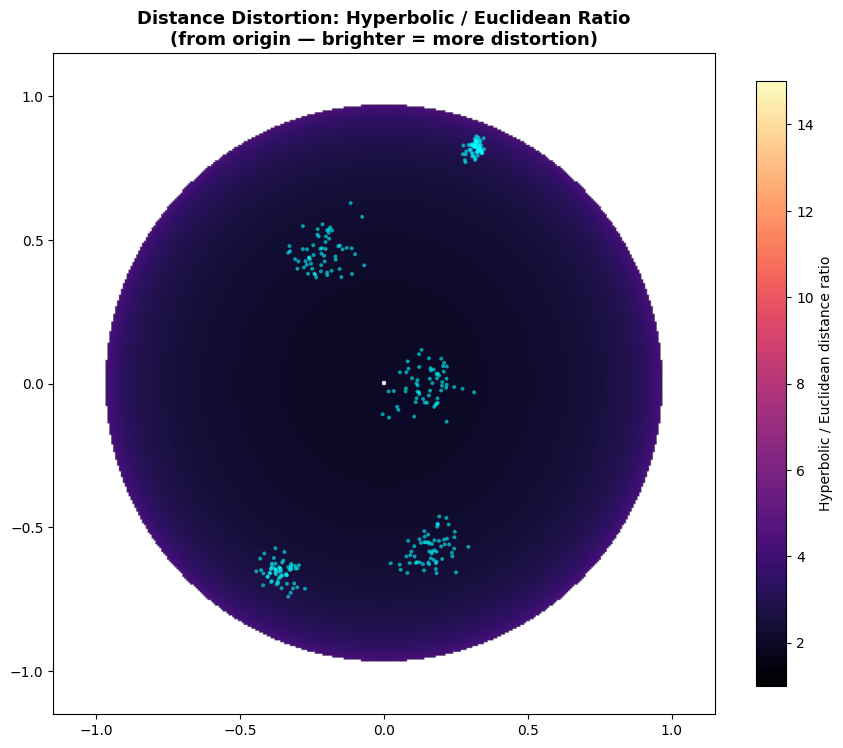

In [9]:
fig, ax = plt.subplots(figsize=(9, 8))

# For each grid point inside the disk, compute ratio of hyperbolic/euclidean distance from origin
grid_norms_euc = np.linalg.norm(grid_pts, axis=1)
inside = grid_norms_euc < 0.97

grid_hyp_dist = np.full(len(grid_pts), np.nan)
grid_hyp_dist[inside] = poincare_distance(grid_pts[inside], np.array([0.0, 0.0]))

grid_euc_dist = np.full(len(grid_pts), np.nan)
grid_euc_dist[inside] = grid_norms_euc[inside]

# Ratio (avoid division by zero)
ratio = np.full(len(grid_pts), np.nan)
valid = inside & (grid_euc_dist > 0.01)
ratio[valid] = grid_hyp_dist[valid] / grid_euc_dist[valid]

ratio_img = ratio.reshape(grid_res, grid_res)

im = ax.imshow(ratio_img, extent=[-1, 1, -1, 1], origin='lower', aspect='equal',
               cmap='magma', vmin=1, vmax=15)

# Disk boundary
boundary = plt.Circle((0, 0), 1, fill=False, color='white', linewidth=2)
ax.add_patch(boundary)

# Plot data points
ax.scatter(points[:, 0], points[:, 1], c='cyan', s=8, alpha=0.6, edgecolors='none')

plt.colorbar(im, ax=ax, label='Hyperbolic / Euclidean distance ratio', shrink=0.8)

ax.set_xlim(-1.15, 1.15)
ax.set_ylim(-1.15, 1.15)
ax.set_aspect('equal')
ax.set_title('Distance Distortion: Hyperbolic / Euclidean Ratio\n(from origin — brighter = more distortion)',
             fontsize=13, fontweight='bold')
ax.grid(False)

plt.tight_layout()
plt.show()

## Choosing K — PVE & Silhouette Analysis

How do we know K = 5 is the right number of clusters? We use two metrics:

**PVE (Proportion of Variance Explained)**

$$\text{PVE}(K) = 1 - \frac{\text{TWCSS}_K}{\text{TWCSS}_1}$$

where $\text{TWCSS}_K$ is the **total within-cluster sum of squared distances** for K clusters and $\text{TWCSS}_1$ is the single-cluster baseline (all points assigned to one cluster). PVE ranges from 0 to 1; an "elbow" in the curve marks a natural K choice.

**Silhouette Score**

For each point $i$:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\, b(i))} \in [-1, +1]$$

where $a(i)$ = mean distance to other points in the **same** cluster (cohesion), and $b(i)$ = mean distance to points in the **nearest other** cluster (separation). Computed from the precomputed pairwise distance matrix so it automatically respects this notebook's metric.

In [ ]:
def silhouette_from_matrix(D, labels):
    """
    Mean silhouette score from a precomputed N×N distance matrix.
    s(i) = (b(i) - a(i)) / max(a(i), b(i))
    """
    n = len(labels)
    unique_clusters = np.unique(labels)
    if len(unique_clusters) <= 1:
        return 0.0
    scores = np.zeros(n)
    for i in range(n):
        ci = labels[i]
        same_mask = (labels == ci).copy()
        same_mask[i] = False
        a_i = float(np.mean(D[i, same_mask])) if np.any(same_mask) else 0.0
        b_i = np.inf
        for cj in unique_clusters:
            if cj == ci:
                continue
            other_mask = (labels == cj)
            if np.any(other_mask):
                b_i = min(b_i, float(np.mean(D[i, other_mask])))
        denom = max(a_i, b_i)
        scores[i] = (b_i - a_i) / denom if denom > 1e-15 else 0.0
    return float(np.mean(scores))

In [ ]:
# Build full N×N Poincaré distance matrix
n_pts = len(points)
print("Building pairwise Poincaré distance matrix...")
D_full = poincare_distance_matrix(points, points)  # N×N

# TWCSS baseline: one cluster, centred on Einstein midpoint of all points
overall_center = einstein_midpoint(points)
TWCSS_1 = float(np.sum(poincare_distance(points, overall_center) ** 2))

K_range = range(2, 11)
pve_vals = []
sil_vals = []

print(f"{'K':>4} {'TWCSS':>10} {'PVE':>8} {'Silhouette':>12}")
print("-" * 38)
for k in K_range:
    lbls_k, cents_k, _ = hyperbolic_kmeans(points, k=k, max_iter=100)
    dists_k = poincare_distance(points, cents_k[lbls_k])
    twcss_k = float(np.sum(dists_k ** 2))
    pve = 1 - twcss_k / TWCSS_1
    sil = silhouette_from_matrix(D_full, lbls_k)
    pve_vals.append(pve)
    sil_vals.append(sil)
    print(f"{k:>4} {twcss_k:>10.4f} {pve:>8.4f} {sil:>12.4f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
K_chosen = 5
K_vals = list(K_range)

ax = axes[0]
ax.plot(K_vals, pve_vals, 'o-', color='#2c3e50', linewidth=2, markersize=7,
        markerfacecolor='#3498db', markeredgecolor='white', markeredgewidth=1.5)
ax.axvline(K_chosen, color='#e74c3c', linestyle='--', linewidth=1.8,
           label=f'Chosen K = {K_chosen}')
ax.fill_between(K_vals, pve_vals, alpha=0.08, color='#3498db')
ax.set_xlabel('Number of Clusters K', fontsize=12)
ax.set_ylabel('PVE', fontsize=12)
ax.set_title('PVE Elbow Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.set_xticks(K_vals); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(K_vals, sil_vals, 's-', color='#2c3e50', linewidth=2, markersize=7,
        markerfacecolor='#9b59b6', markeredgecolor='white', markeredgewidth=1.5)
best_k_sil = K_vals[int(np.argmax(sil_vals))]
ax.axvline(best_k_sil, color='#9b59b6', linestyle='--', linewidth=1.8,
           label=f'Best silhouette K = {best_k_sil}')
ax.axvline(K_chosen, color='#e74c3c', linestyle=':', linewidth=1.8,
           label=f'Chosen K = {K_chosen}')
ax.fill_between(K_vals, sil_vals, alpha=0.08, color='#9b59b6')
ax.set_xlabel('Number of Clusters K', fontsize=12)
ax.set_ylabel('Mean Silhouette Score', fontsize=12)
ax.set_title('Silhouette Score vs K', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.set_xticks(K_vals); ax.grid(True, alpha=0.3)

plt.suptitle('Choosing K: PVE & Silhouette Validation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nK=2..10 summary:")
print(f"{'K':>4} {'PVE':>8} {'Silhouette':>12}")
print("-" * 27)
for k, pve, sil in zip(K_vals, pve_vals, sil_vals):
    marker = " ◄ chosen" if k == K_chosen else ""
    print(f"{k:>4} {pve:>8.4f} {sil:>12.4f}{marker}")

## 6. Summary

| Aspect | Euclidean K-Means | Hyperbolic K-Means |
|--------|------------------|--------------------|
| **Space** | Flat $\mathbb{R}^n$ | Poincaré disk $\mathbb{D}^n$ |
| **Distance** | $\|u - v\|$ | $\text{arcosh}\left(1 + \frac{2\|u-v\|^2}{(1-\|u\|^2)(1-\|v\|^2)}\right)$ |
| **Centroid** | Arithmetic mean | Einstein midpoint (via Klein model) |
| **Geometry** | Uniform — same everywhere | Expansive near boundary — distances explode |
| **Best for** | General flat data | Hierarchical / tree-structured data |

### Key Takeaways

1. **Near-boundary clusters** are the key differentiator: Euclidean sees them as tiny; hyperbolic sees them as properly spread out, giving them fair cluster boundaries.

2. **The distortion map** (Section 5d) captures this visually — near the center, both metrics agree; near the boundary, hyperbolic distance can be 10–15× larger.

3. **Practical application:** When embedding hierarchical data (e.g., Poincaré embeddings for knowledge graphs), using hyperbolic K-means respects the embedding geometry, while Euclidean K-means would give misleading clusters.

### Next: Torus
In the next notebook, we'll explore clustering on a **torus** — a surface with two periodic dimensions, ideal for data like time-of-day × day-of-week.